# Tratamento da imagem do cachorro

Este notebook documenta a primeira parte da atividade **Turtle Draw** onde prepara a imagem para que, seja possível extrair um contorno minimamente bom o suficiente para ser seguido pela tartaruga no `turtlesim`.

Aqui ainda nao vamos resolver o planejamento do caminho no ROS. Este notebook busca entender e justificar o tratamento da imagem antes de transformar o contorno em passos a serem seguidos pelo `turtlesim`.


In [75]:
from pathlib import Path

import cv2 
import matplotlib.pyplot as plt
import numpy as np

CAMINHO_IMAGEM = Path("dog_img/dog.jpg")

plt.rcParams["figure.figsize"] = (12, 6)
plt.rcParams["image.cmap"] = "gray"

## 1. Carregamento e diagnostico inicial

A imagem do cachorro tem um fundo claro e um cachorro escuro no lado esquerdo. Isso deixa mais simples para separar cachorro e fundo, porém pode causar alguns problemas:

- o fundo tem ruído e textura, então uma detecção de borda direta pode capturar muitos pontos irrelevantes;
- o cachorro tem regiões muito escuras, onde detalhes internos podem virar bordas falsas;
- existe bastante espaço vazio a direita, que não ajuda no desenho e aumenta o custo do processamento.

Por causa disso, o tratamento vai buscar uma imagem reduzida e limpa que possua um contraste mais controlado.


Formato: (720, 1280, 3)
Menor valor: 0.0
Maior valor: 1.0


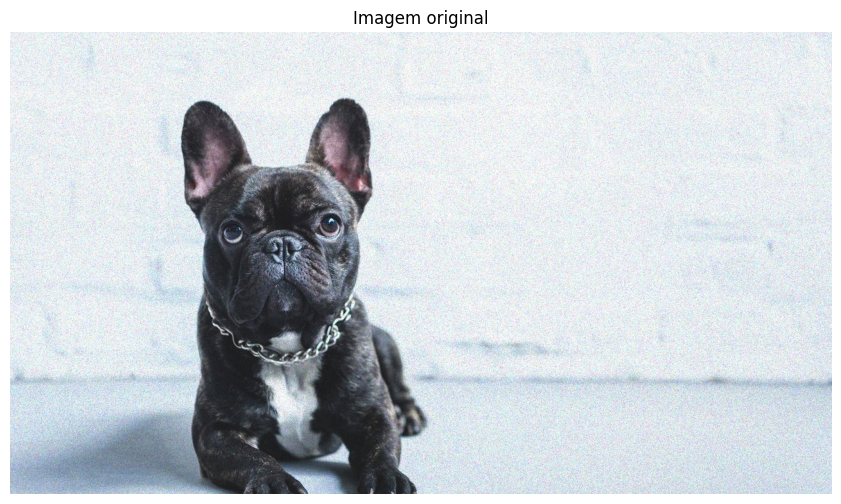

In [76]:
imagem_bgr = cv2.imread(str(CAMINHO_IMAGEM), cv2.IMREAD_COLOR)
if imagem_bgr is None:
    raise FileNotFoundError(f"Imagem nao encontrada: {CAMINHO_IMAGEM}")

# cv2.imread retorna BGR. A conversao para RGB abaixo e apenas reordenacao de canais.
imagem_rgb = imagem_bgr[..., ::-1].astype(np.float32) / 255.0

print("Formato:", imagem_rgb.shape)
print("Menor valor:", imagem_rgb.min())
print("Maior valor:", imagem_rgb.max())

plt.imshow(imagem_rgb)
plt.title("Imagem original")
plt.axis("off");

## 2. Conversão manual para tons de cinza

Para encontrar bordas, não precisamos trabalhar com três canais de cor. Vamos converter a imagem para intensidade luminosa usando os pesos perceptuais:

`gray = 0.299 R + 0.587 G + 0.114 B`

Esses pesos refletem que o olho humano percebe o canal verde com mais intensidade do que vermelho e azul. Isso preserva melhor a estrutura visual do objeto do que uma média simples.


(np.float64(-0.5), np.float64(1279.5), np.float64(719.5), np.float64(-0.5))

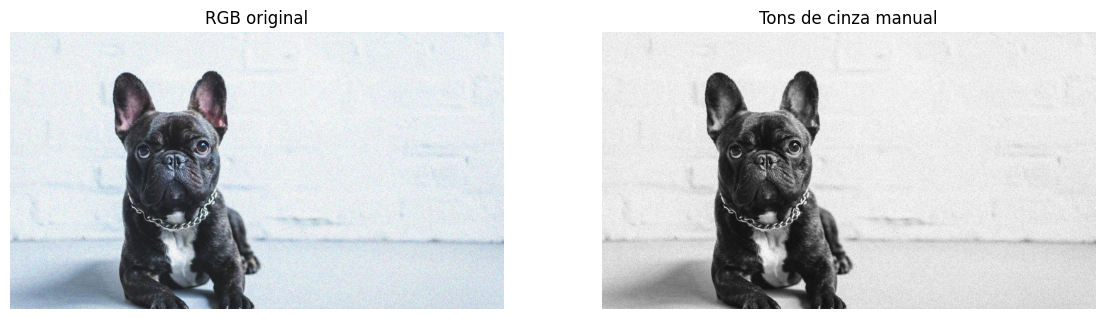

In [77]:
def converter_para_cinza(imagem_rgb):
    pesos_luminosidade = np.array([0.299, 0.587, 0.114], dtype=np.float32)
    return imagem_rgb @ pesos_luminosidade


imagem_cinza = converter_para_cinza(imagem_rgb)

figura, eixos = plt.subplots(1, 2, figsize=(14, 5))
eixos[0].imshow(imagem_rgb)
eixos[0].set_title("RGB original")
eixos[0].axis("off")
eixos[1].imshow(imagem_cinza)
eixos[1].set_title("Tons de cinza manual")
eixos[1].axis("off")

## 3. Recorte da região útil

A imagem tem muito fundo vazio a direita. Para o objetivo de desenhar o cachorro, esse fundo não contribui e ainda aumenta a chance de detectarmos textura como borda.

Neste primeiro tratamento, vamos fazer um recorte manual conservador que mantém o cachorro inteiro e remove parte do espaço vazio. Essa decisão é aceitável aqui porque a atividade trabalha com uma imagem específica. Depois, se quisermos generalizar, podemos trocar por uma segmentação automática.


(np.float64(-0.5), np.float64(509.5), np.float64(669.5), np.float64(-0.5))

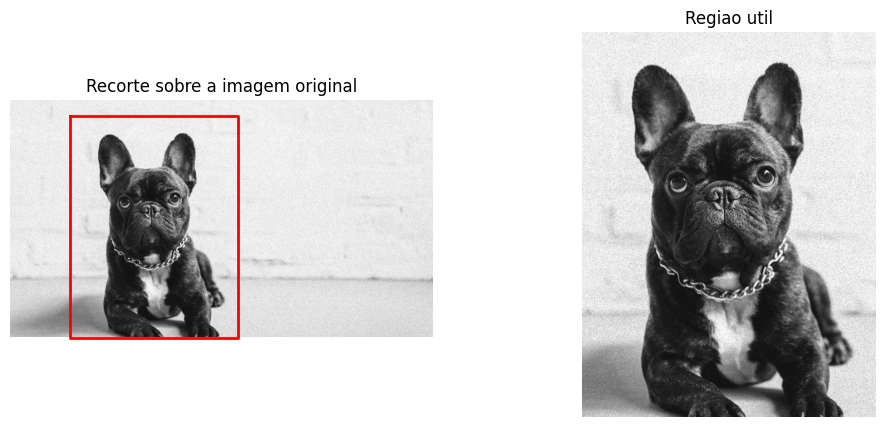

In [78]:
y_inicial, y_final = 50, 720
x_inicial, x_final = 180, 690

recorte_cinza = imagem_cinza[y_inicial:y_final, x_inicial:x_final]

figura, eixos = plt.subplots(1, 2, figsize=(12, 5))
eixos[0].imshow(imagem_cinza)
eixos[0].plot(
    [x_inicial, x_final, x_final, x_inicial, x_inicial],
    [y_inicial, y_inicial, y_final, y_final, y_inicial],
    color="red",
    linewidth=2,
)
eixos[0].set_title("Recorte sobre a imagem original")
eixos[0].axis("off")
eixos[1].imshow(recorte_cinza)
eixos[1].set_title("Regiao util")
eixos[1].axis("off")

## 4. Redimensionamento por amostragem bilinear

O `turtlesim` desenha em um espaço pequeno, então não precisamos manter todos os pixels da imagem original. Reduzir a imagem deixa a detecção de bordas e o caminho final mais simples.

Vamos implementar uma interpolação bilinear simples com `NumPy`. Ela evita a aparência muito quebrada de uma redução por vizinho mais próximo.


(np.float64(-0.5), np.float64(279.5), np.float64(359.5), np.float64(-0.5))

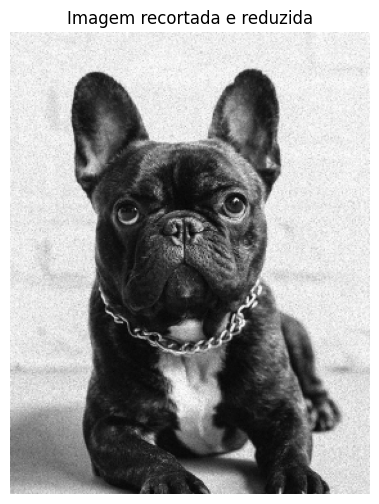

In [79]:
def redimensionar_bilinear(imagem, nova_altura, nova_largura):
    altura, largura = imagem.shape[:2]
    posicoes_y = np.linspace(0, altura - 1, nova_altura)
    posicoes_x = np.linspace(0, largura - 1, nova_largura)
    grade_x, grade_y = np.meshgrid(posicoes_x, posicoes_y)

    x0 = np.floor(grade_x).astype(int)
    y0 = np.floor(grade_y).astype(int)
    x1 = np.clip(x0 + 1, 0, largura - 1)
    y1 = np.clip(y0 + 1, 0, altura - 1)

    peso_x = grade_x - x0
    peso_y = grade_y - y0

    topo = (1 - peso_x) * imagem[y0, x0] + peso_x * imagem[y0, x1]
    base = (1 - peso_x) * imagem[y1, x0] + peso_x * imagem[y1, x1]
    return (1 - peso_y) * topo + peso_y * base


imagem_reduzida = redimensionar_bilinear(recorte_cinza, 360, 280)

plt.imshow(imagem_reduzida)
plt.title("Imagem recortada e reduzida")
plt.axis("off")

## 5. Suavização gaussiana implementada manualmente

Antes de detectar bordas, suavizamos a imagem para reduzir ruído fino do fundo e da pelagem. A ideia é simples: cada pixel passa a representar uma média ponderada dos vizinhos, com mais peso no centro.

Usaremos um filtro gaussiano pequeno. Ele preserva melhor as transições principais do que uma média uniforme, porque não espalha tanto a informação de pixels distantes.


(np.float64(-0.5), np.float64(279.5), np.float64(359.5), np.float64(-0.5))

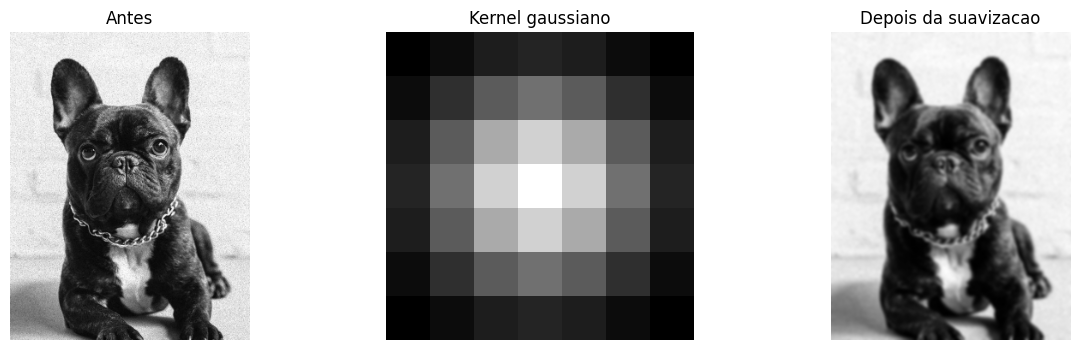

In [80]:
def criar_kernel_gaussiano(tamanho=7, sigma=1.6):
    if tamanho % 2 == 0:
        raise ValueError("O tamanho do kernel deve ser impar.")
    raio = tamanho // 2
    eixo = np.arange(-raio, raio + 1)
    grade_x, grade_y = np.meshgrid(eixo, eixo)
    kernel = np.exp(-(grade_x**2 + grade_y**2) / (2 * sigma**2))
    return kernel / kernel.sum()


def convoluir_2d(imagem, kernel):
    altura_kernel, largura_kernel = kernel.shape
    borda_y, borda_x = altura_kernel // 2, largura_kernel // 2
    imagem_com_borda = np.pad(imagem, ((borda_y, borda_y), (borda_x, borda_x)), mode="edge")
    saida = np.zeros_like(imagem, dtype=np.float32)

    for y in range(imagem.shape[0]):
        for x in range(imagem.shape[1]):
            regiao = imagem_com_borda[y:y + altura_kernel, x:x + largura_kernel]
            saida[y, x] = np.sum(regiao * kernel)
    return saida


kernel_gaussiano = criar_kernel_gaussiano(tamanho=7, sigma=1.6)
imagem_suavizada = convoluir_2d(imagem_reduzida, kernel_gaussiano)

figura, eixos = plt.subplots(1, 3, figsize=(15, 4))
eixos[0].imshow(imagem_reduzida)
eixos[0].set_title("Antes")
eixos[0].axis("off")
eixos[1].imshow(kernel_gaussiano)
eixos[1].set_title("Kernel gaussiano")
eixos[1].axis("off")
eixos[2].imshow(imagem_suavizada)
eixos[2].set_title("Depois da suavizacao")
eixos[2].axis("off")

## 6. Normalização de contraste por percentis

A imagem tem fundo muito claro e cachorro muito escuro. Para deixar as transições mais consistentes, vamos espalhar os valores de intensidade usando percentis.

Em vez de usar mínimo e máximo absolutos, usamos percentis 2% e 98%. Isso reduz o efeito de pontos extremos causados por ruído ou brilho localizado.


(np.float64(-0.5), np.float64(279.5), np.float64(359.5), np.float64(-0.5))

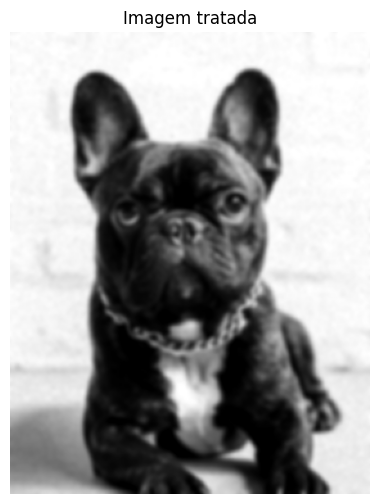

In [81]:
def normalizar_por_percentis(imagem, percentil_baixo=2, percentil_alto=98):
    valor_baixo, valor_alto = np.percentile(imagem, [percentil_baixo, percentil_alto])
    normalizada = (imagem - valor_baixo) / (valor_alto - valor_baixo + 1e-8)
    return np.clip(normalizada, 0, 1)


imagem_tratada = normalizar_por_percentis(imagem_suavizada)

plt.figure(figsize=(6, 6))
plt.imshow(imagem_tratada)
plt.title("Imagem tratada")
plt.axis("off")

## 7. Borda preliminar com Sobel manual

Embora o foco deste notebook seja tratamento, vale calcular uma borda preliminar para avaliar se as decisões anteriores ajudaram. Vamos implementar os filtros de Sobel manualmente.

O Sobel estima a variação horizontal e vertical da intensidade. A magnitude do gradiente fica alta onde há mudança brusca, que normalmente corresponde a bordas.


(np.float64(-0.5), np.float64(279.5), np.float64(359.5), np.float64(-0.5))

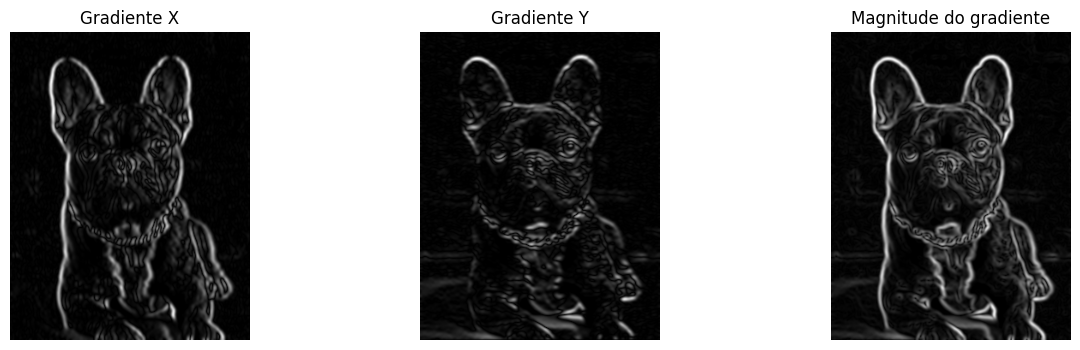

In [82]:
kernel_sobel_x = np.array([[-1, 0, 1], [-2, 0, 2], [-1, 0, 1]], dtype=np.float32)
kernel_sobel_y = np.array([[-1, -2, -1], [0, 0, 0], [1, 2, 1]], dtype=np.float32)

gradiente_x = convoluir_2d(imagem_tratada, kernel_sobel_x)
gradiente_y = convoluir_2d(imagem_tratada, kernel_sobel_y)
magnitude_gradiente = np.sqrt(gradiente_x**2 + gradiente_y**2)
magnitude_gradiente = magnitude_gradiente / (magnitude_gradiente.max() + 1e-8)

figura, eixos = plt.subplots(1, 3, figsize=(15, 4))
eixos[0].imshow(np.abs(gradiente_x))
eixos[0].set_title("Gradiente X")
eixos[0].axis("off")
eixos[1].imshow(np.abs(gradiente_y))
eixos[1].set_title("Gradiente Y")
eixos[1].axis("off")
eixos[2].imshow(magnitude_gradiente)
eixos[2].set_title("Magnitude do gradiente")
eixos[2].axis("off")

## 8. Limiar para visualizar as bordas candidatas

Para enxergar melhor o resultado, aplicamos um limiar sobre a magnitude do gradiente. Aqui usamos percentil porque a escala do gradiente depende da imagem e do filtro.

Esse ainda não é o contorno final para o cachorro. Ele é um diagnóstico que mostra se o tratamento deixou as bordas principais fortes e reduziu ruído suficiente para a próxima etapa.


(np.float64(-0.5), np.float64(279.5), np.float64(359.5), np.float64(-0.5))

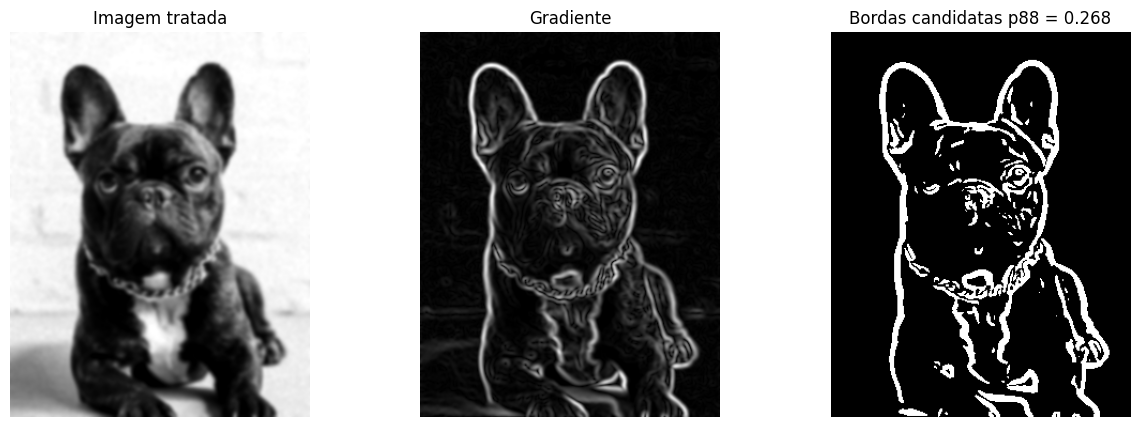

In [83]:
limiar_borda = np.percentile(magnitude_gradiente, 88)
bordas_candidatas = magnitude_gradiente >= limiar_borda

figura, eixos = plt.subplots(1, 3, figsize=(15, 5))
eixos[0].imshow(imagem_tratada)
eixos[0].set_title("Imagem tratada")
eixos[0].axis("off")
eixos[1].imshow(magnitude_gradiente)
eixos[1].set_title("Gradiente")
eixos[1].axis("off")
eixos[2].imshow(bordas_candidatas)
eixos[2].set_title(f"Bordas candidatas p88 = {limiar_borda:.3f}")
eixos[2].axis("off")